[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/catboost_sglb_knowledge_uncertainty.ipynb)

# CatBoost SGLB: what knowledge uncertainty does and does not tell you

`posterior_sampling=True` trains a CatBoost model with Stochastic Gradient Langevin Boosting. The
run then behaves like a Markov chain, and `virtual_ensembles_predict` slices that single model into
sub-models. Their disagreement is reported as knowledge uncertainty, the model's own estimate of
where it is on unfamiliar ground.

This notebook checks that estimate against the truth. The data comes from a known 2D function, so
for any point we can measure both the knowledge uncertainty and the actual error, and see whether
the two agree.

Three regions are tested: a well covered part of the training range, a square gap cut out of the
training data, and a region 8 units past the edge of the range.

Runtime is about two minutes on a free Colab CPU.

In [1]:
try:
    import catboost
except ImportError:
    !pip install -q catboost

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from catboost import CatBoostRegressor

LO, HI, N = 0.0, 10.0, 6000
HOLE = (3.0, 7.0)
ITERS, LR, SLICES = 1000, 0.2, 10


def surface(X):
    return 3 * np.sin(X[:, 0]) + 2 * np.cos(1.5 * X[:, 1]) + 0.8 * X[:, 0] * np.sin(X[:, 1])


def build(seed):
    rng = np.random.default_rng(seed)
    X = rng.uniform(LO, HI, size=(N, 2))
    gap = ((X[:, 0] > HOLE[0]) & (X[:, 0] < HOLE[1]) &
           (X[:, 1] > HOLE[0]) & (X[:, 1] < HOLE[1]))
    X = X[~gap]
    return X, surface(X) + rng.normal(0, 0.3, len(X))


def regions(seed, n=800):
    rng = np.random.default_rng(1000 + seed)
    return {"support": rng.uniform(0.3, 2.7, size=(n, 2)),
            "hole": rng.uniform(HOLE[0] + 0.3, HOLE[1] - 0.3, size=(n, 2)),
            "far": rng.uniform(HI + 8, HI + 10, size=(n, 2))}


def sglb(X, y, seed):
    m = CatBoostRegressor(loss_function="RMSEWithUncertainty", posterior_sampling=True,
                          iterations=ITERS, learning_rate=LR, random_seed=seed, verbose=0)
    m.fit(X, y)
    return m

## What the flag actually sets

`posterior_sampling=True` is a shortcut for three settings. It turns on Langevin noise, sets the
shrinkage to `1 / (2N)` and the diffusion temperature to `N`, where `N` is the number of training
rows.

In [3]:
X, y = build(0)
m = sglb(X, y, 0)
p = m.get_all_params()
print(f"training rows          {len(y)}")
for k in ("posterior_sampling", "model_shrink_mode", "model_shrink_rate", "diffusion_temperature"):
    print(f"{k:22s} {p[k]}")
print(f"\n1 / (2N) = {1 / (2 * len(y)):.8f}")

training rows          5040
posterior_sampling     True
model_shrink_mode      Constant
model_shrink_rate      9.920635056914762e-05
diffusion_temperature  5040

1 / (2N) = 0.00009921


`virtual_ensembles_predict` with `prediction_type="TotalUncertainty"` returns three columns for
`RMSEWithUncertainty`: the mean prediction, knowledge uncertainty, and data uncertainty.

In [4]:
R = regions(0)
out = m.virtual_ensembles_predict(R["support"][:4], prediction_type="TotalUncertainty",
                                  virtual_ensembles_count=SLICES)
print(pd.DataFrame(np.asarray(out),
                   columns=["mean", "knowledge", "data"]).round(5).to_string(index=False))

   mean  knowledge    data
2.65372    0.00025 0.03585
4.34131    0.00003 0.01531
4.45853    0.00002 0.06645
1.18037    0.00007 0.04396


## Signal against truth, 10 seeds

Everything below is a ratio against the well covered region, because the absolute values are tiny
and mean nothing on their own. For each seed the table gives how much the knowledge uncertainty
rises in a region, next to how much the actual error rises there.

In [5]:
rows, corrs = [], []
for seed in range(10):
    X, y = build(seed)
    R = regions(seed)
    m = sglb(X, y, seed)

    o, ku_all, err_all = {}, [], []
    for name, Xr in R.items():
        pred = np.asarray(m.virtual_ensembles_predict(Xr, prediction_type="TotalUncertainty",
                                                      virtual_ensembles_count=SLICES))
        err = np.abs(surface(Xr) - pred[:, 0])
        o[f"ku_{name}"], o[f"mae_{name}"] = pred[:, 1].mean(), err.mean()
        o[f"data_{name}"] = pred[:, 2].mean()
        ku_all.append(pred[:, 1])
        err_all.append(err)

    corrs.append(spearmanr(np.concatenate(ku_all), np.concatenate(err_all)).statistic)
    rows.append({"seed": seed,
                 "ku_on_covered_data": o["ku_support"],
                 "data_unc_on_covered_data": o["data_support"],
                 "hole_signal_x": o["ku_hole"] / o["ku_support"],
                 "hole_error_x": o["mae_hole"] / o["mae_support"],
                 "far_signal_x": o["ku_far"] / o["ku_support"],
                 "far_error_x": o["mae_far"] / o["mae_support"]})

single = pd.DataFrame(rows)
print(single.drop(columns=["ku_on_covered_data", "data_unc_on_covered_data"]).round(2).to_string(index=False))
print()
print(single.drop(columns=["seed", "ku_on_covered_data", "data_unc_on_covered_data"])
      .agg(["mean", "min", "max"]).round(2).to_string())
print()
print(f"on covered data, knowledge uncertainty {single.ku_on_covered_data.mean():.6f} "
      f"and data uncertainty {single.data_unc_on_covered_data.mean():.4f}, "
      f"a factor of {single.data_unc_on_covered_data.mean() / single.ku_on_covered_data.mean():.0f}")

 seed  hole_signal_x  hole_error_x  far_signal_x  far_error_x
    0           2.01         16.75          7.04        87.75
    1           2.59         23.50          9.44        96.63
    2           1.68         21.83          8.92        95.64
    3           1.35         26.54          0.77        94.90
    4           1.86         21.67          1.20        88.48
    5           1.30         17.92         14.52        89.87
    6           1.72         18.31          2.98        98.92
    7           2.27         22.40          0.88        95.94
    8           1.94         19.19          1.76        95.72
    9           1.52         25.57          1.09       105.34

      hole_signal_x  hole_error_x  far_signal_x  far_error_x
mean           1.82         21.37          4.86        94.92
min            1.30         16.75          0.77        87.75
max            2.59         26.54         14.52       105.34

on covered data, knowledge uncertainty 0.000248 and data uncertainty 0.0

The ranking is right and the scale is not. The gap and the far region both come out more uncertain
than the covered region on average, but the signal rises by a factor of two to five where the error
rises by a factor of twenty to ninety.

The far region is worse than that. Look at how many seeds gave no usable signal at all in the place
where the model is most wrong.

In [6]:
flat = (single.far_signal_x < 1.5).sum()
print(f"seeds where the far region signal stayed under 1.5x: {flat} of {len(single)}")
print(f"average error in that same region: {single.far_error_x.mean():.0f}x the covered region")
print()
print(f"Spearman(knowledge uncertainty, |error|) pooled over the three regions:")
print(f"  mean {np.mean(corrs):.2f}, min {np.min(corrs):.2f}, max {np.max(corrs):.2f}")

seeds where the far region signal stayed under 1.5x: 4 of 10
average error in that same region: 95x the covered region

Spearman(knowledge uncertainty, |error|) pooled over the three regions:
  mean 0.47, min 0.20, max 0.68


## More slices do not help

`virtual_ensembles_count` sets how many sub-models the single run is cut into. They all come from
one tree sequence, so they are correlated and cutting more of them adds little.

In [7]:
X, y = build(0)
R = regions(0)
m = sglb(X, y, 0)
for c in (5, 10, 25, 50):
    ku = {k: np.asarray(m.virtual_ensembles_predict(Xr, prediction_type="TotalUncertainty",
                                                    virtual_ensembles_count=c))[:, 1].mean()
          for k, Xr in R.items()}
    print(f"count={c:3d}   hole {ku['hole'] / ku['support']:5.2f}x   far {ku['far'] / ku['support']:5.2f}x")

count=  5   hole  2.39x   far 10.97x
count= 10   hole  2.01x   far  7.04x
count= 25   hole  2.01x   far  7.63x
count= 50   hole  1.96x   far  7.46x


## What a real ensemble gives instead

Ten independently trained SGLB models on the same data, with knowledge uncertainty taken as the
variance of their mean predictions. This costs ten fits instead of one.

In [8]:
ens = []
for data_seed in range(3):
    X, y = build(data_seed)
    R = regions(data_seed)
    preds = {k: [] for k in R}
    for s in range(10):
        mm = sglb(X, y, s)
        for k, Xr in R.items():
            preds[k].append(mm.predict(Xr)[:, 0])

    var = {k: np.var(np.array(v), axis=0).mean() for k, v in preds.items()}
    mae = {k: np.abs(surface(R[k]) - np.array(v).mean(axis=0)).mean() for k, v in preds.items()}
    ens.append({"data_seed": data_seed,
                "hole_signal_x": var["hole"] / var["support"],
                "hole_error_x": mae["hole"] / mae["support"],
                "far_signal_x": var["far"] / var["support"],
                "far_error_x": mae["far"] / mae["support"],
                "support_variance": var["support"]})

ensemble = pd.DataFrame(ens)
print(ensemble.drop(columns="support_variance").round(2).to_string(index=False))
print()
print(f"absolute signal on covered data: {ensemble.support_variance.mean():.6f}, "
      f"{ensemble.support_variance.mean() / single.ku_on_covered_data.mean():.0f}x the virtual one")

 data_seed  hole_signal_x  hole_error_x  far_signal_x  far_error_x
         0          21.40         27.31          5.53       124.15
         1          34.81         28.50          5.51       131.99
         2          36.03         29.81          0.07       132.40

absolute signal on covered data: 0.007481, 30x the virtual one


Inside the training range the real ensemble tracks the error closely, and its absolute values are
roughly forty times larger than the virtual ones, so there is far more resolution to work with.

Past the edge of the range it is not reliable either. On one of the three datasets it reported the
far region as more confident than well covered data, while the model was over a hundred times more
wrong there.

## The chart

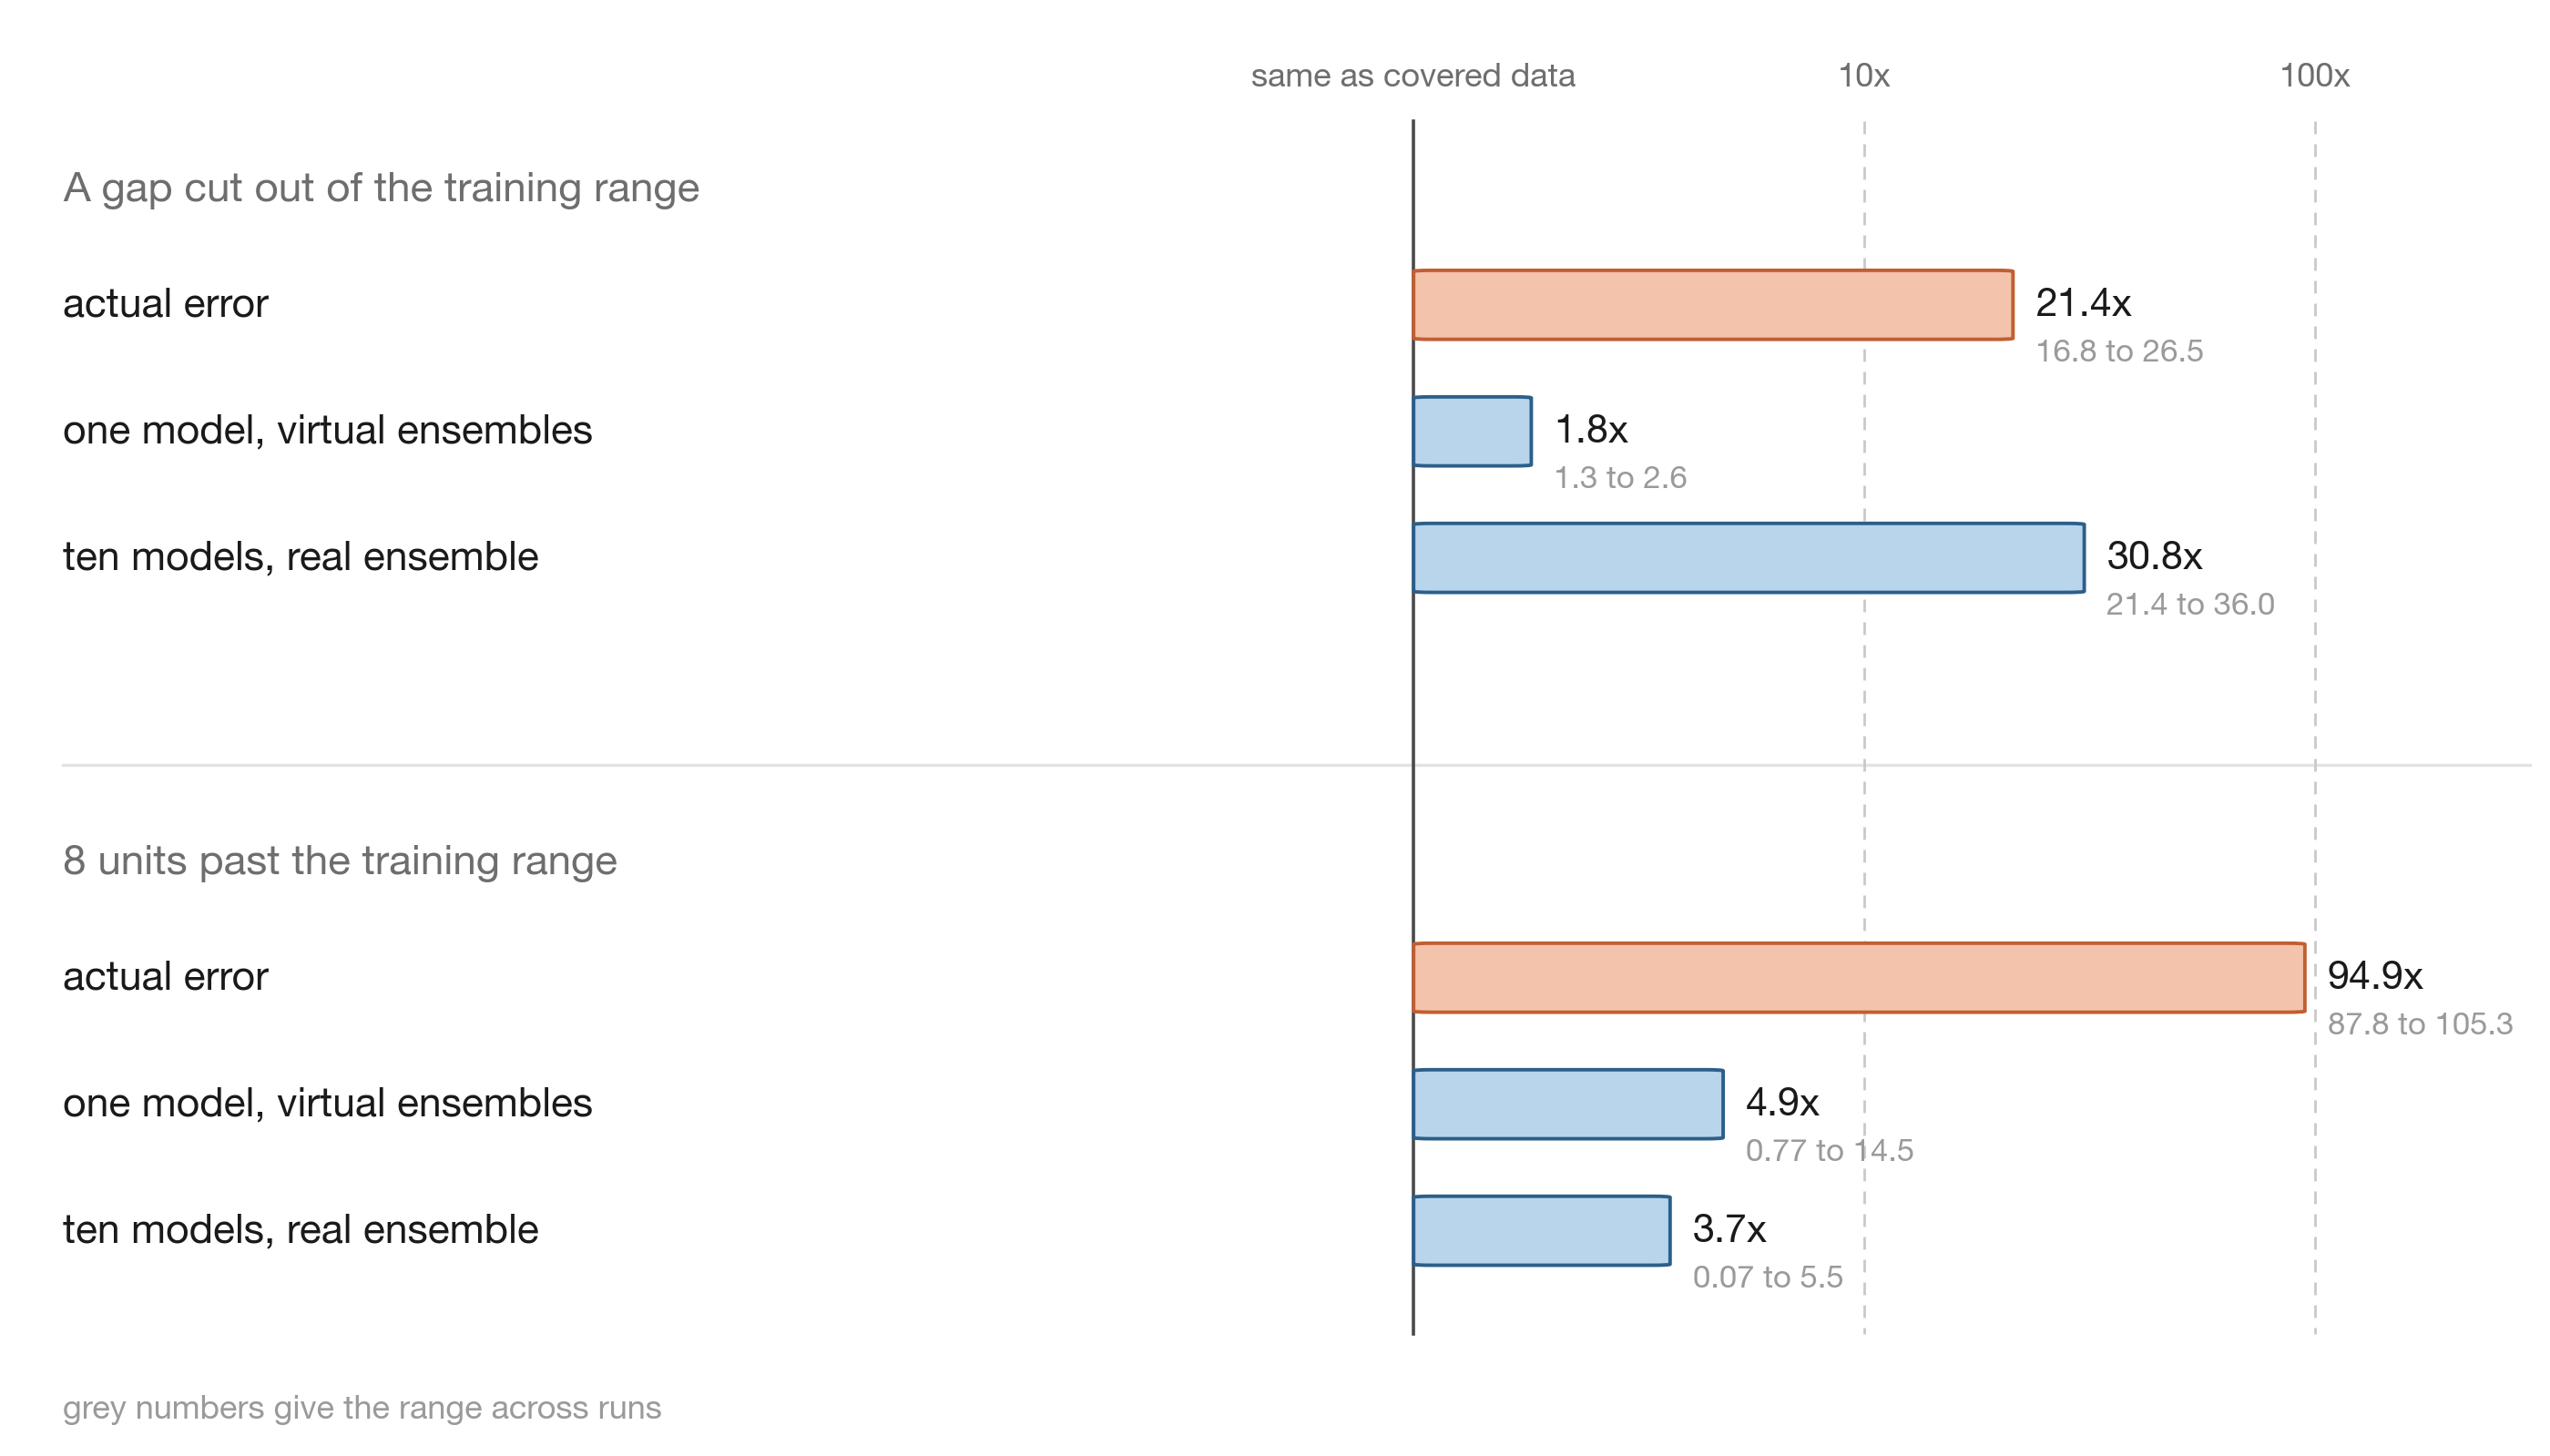

In [9]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
BLUE_F, BLUE_E = "#B9D5EC", "#2C5F8A"
CORAL_F, CORAL_E = "#F4C3AC", "#C05F32"
INK, GREY, GREY2 = "#1a1a1a", "#6e6e6e", "#9a9a9a"

def spread(col):
    return col.mean(), (col.min(), col.max())

panels = [
    ("A gap cut out of the training range", [
        ("actual error", *spread(single.hole_error_x), CORAL_F, CORAL_E),
        ("one model, virtual ensembles", *spread(single.hole_signal_x), BLUE_F, BLUE_E),
        ("ten models, real ensemble", *spread(ensemble.hole_signal_x), BLUE_F, BLUE_E)]),
    ("8 units past the training range", [
        ("actual error", *spread(single.far_error_x), CORAL_F, CORAL_E),
        ("one model, virtual ensembles", *spread(single.far_signal_x), BLUE_F, BLUE_E),
        ("ten models, real ensemble", *spread(ensemble.far_signal_x), BLUE_F, BLUE_E)]),
]

XMIN, XMAX = np.log10(0.9), np.log10(115)
LEFT, BH = XMIN - 3.05, 0.6
fig_w, fig_h = 13.8, 7.8
fig = plt.figure(figsize=(fig_w, fig_h), dpi=200)
ax = fig.add_axes([0, 0, 1, 1])

rows_, marks, y = [], [], 0.95
for pi, (title, entries) in enumerate(panels):
    if pi:
        y += 0.7
        marks.append(("divider", y, None))
        y += 0.85
    marks.append(("title", y, title))
    y += 1.0
    for e in entries:
        rows_.append((y,) + e)
        y += 1.1
YMAX = y + 0.7

ax.set_xlim(LEFT, XMAX + 0.42)
ax.set_ylim(YMAX, -0.55)
ax.axis("off")
mut = ((XMAX + 0.42 - LEFT) / fig_w) / ((YMAX + 0.55) / fig_h)

for tick in (1, 10, 100):
    x = np.log10(tick)
    one = tick == 1
    ax.add_line(Line2D([x, x], [0.35, YMAX - 0.9], color="#4a4a4a" if one else "#c9c9c9",
                       lw=1.3 if one else 1.0, ls="-" if one else (0, (5, 4)), zorder=1))
    ax.text(x, 0.10, "same as covered data" if one else f"{tick}x",
            ha="center", va="bottom", fontsize=13, color=GREY)

for kind, y_, txt in marks:
    if kind == "divider":
        ax.add_line(Line2D([LEFT + 0.1, XMAX + 0.5], [y_, y_], color="#e2e2e2", lw=1.2, zorder=0))
    else:
        ax.text(LEFT + 0.1, y_, txt, ha="left", va="center", fontsize=16.5, color=GREY, zorder=4,
                bbox=dict(facecolor="white", edgecolor="none", pad=2.5))

fmt = lambda v: f"{v:.2f}" if v < 1 else f"{v:.1f}"
for y_, name, val, rng, fc, ec in rows_:
    x1 = np.log10(val)
    ax.add_patch(FancyBboxPatch((0, y_ - BH / 2), x1, BH,
                                boxstyle="round,pad=0,rounding_size=0.04", mutation_aspect=mut,
                                facecolor=fc, edgecolor=ec, lw=1.4, zorder=3))
    ax.text(LEFT + 0.1, y_, name, ha="left", va="center", fontsize=16, color=INK)
    ax.text(x1 + 0.05, y_, f"{val:.1f}x", ha="left", va="center", fontsize=15.5, color=INK)
    ax.text(x1 + 0.05, y_ + 0.42, f"{fmt(rng[0])} to {fmt(rng[1])}",
            ha="left", va="center", fontsize=12.5, color=GREY2)

ax.text(LEFT + 0.1, YMAX - 0.25, "grey numbers give the range across runs",
        ha="left", va="center", fontsize=13, color=GREY2)

fig.savefig("catboost_sglb_knowledge_uncertainty.png", facecolor="white")
plt.show()

## Takeaway

Knowledge uncertainty from a single SGLB run ranks the regions correctly on average, and that is
worth something for one extra flag and no extra fits. What it does not give you is scale. The gap
raised the error by 21x and the signal by 1.8x, and past the edge of the training range four seeds
out of ten produced no signal at all where the model was 95x more wrong.

Two practical points follow. Compare regions against each other rather than against a fixed
threshold, since the absolute numbers are around 1e-4 and carry no meaning on their own. And before
shipping this as a detector, run your own out-of-domain examples across several seeds, because a
single run can land anywhere in the range above.

A real ensemble costs ten fits and tracks the error closely inside the training range. Neither
version is dependable past the edge of it.